# Capital Asset Pricing Model (CAPM)

The Capital Asset Pricing Model (CAPM) is one of the most widely used formula in finance. It describes the relationship between the expected return of assets and the systematic risk of the market.

According to CAPM, an asset’s expected return consists of the risk-free rate plus an additional premium that compensates investors for taking on market risk. The model assumes investors behave rationally, seeking to maximize returns while minimizing risk. Its primary purpose is to estimate the return an investor should require for bearing a specific level of systematic risk above the risk-free rate.

The Capital Asset Pricing Model (CAPM) is given by:

$$
E[R_i] = R_f + \beta_i \left( E[R_m] - R_f \right)
$$

Where:

- $E[R_i]$ = Expected return of asset $i$  
- $R_f$ = Risk-free rate  
- $\beta_i$ = Beta of asset $i$ (systematic risk)  
- $E[R_m]$ = Expected return of the market  
- $(E[R_m] - R_f)$ = Market risk premium

#### Example of CAPM Application

Consider a simple illustration of the CAPM using Apple stock.  
Assume the following hypothetical inputs:

- Risk-free rate ($R_f$) = 0%  
- Expected market return ($E[R_m]$) = 12.4%  
- Beta of Apple ($\beta_i$) = 1.11  

Using the CAPM formula:

$$
E[R_i] = R_f + \beta_i \left( E[R_m] - R_f \right)
$$

Substituting the values:

$$
E[R_i] = 0\% + 1.11 \times (12.4\% - 0\%)
$$

$$
E[R_i] = 13.7\%
$$

Based on these assumptions, CAPM estimates that Apple should deliver an expected return of **13.7%**. This means investors would require approximately 13.7% to be adequately compensated for the level of systematic risk (beta = 1.11) associated with holding the stock.


With that, let us begin our analysis on a basket of stocks from 2020 to 2025

In [48]:
import pandas as pd
import numpy as np
import math
import yfinance as yf
from matplotlib import pyplot as plt
import plotly.express as px

#### Step 1: Download the Data

In [49]:
# Initialize parameters
risk_free_rate = 0.02  # Risk-free rate (e.g., 2%)
market_return = 0.08    # Expected market return (e.g., 8%)
stock_tickers = ['AAPL', 'BA', 'AMZN', 'MSFT', 'TSLA', 'GOOGL', 'META', 'IBM']  # List of stock tickers
index_ticker = '^GSPC'  # S&P 500 index ticker
start_date = '2020-01-01'
end_date = '2025-01-01'

In [50]:
# Add the index ticker to the list of stock tickers
stock_tickers.append(index_ticker)
stocks_df = yf.download(stock_tickers, start=start_date, end=end_date)['Close']
stocks_df = stocks_df.dropna()
stocks_df.head()

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_19013/1827491789.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  9 of 9 completed


Ticker,AAPL,AMZN,BA,GOOGL,IBM,META,MSFT,TSLA,^GSPC
Date,,,,,,,,,
2020-01-02,72.400520,94.900497,331.348572,67.920815,99.446747,208.324783,152.505707,28.684000,3257.850098
2020-01-03,71.696648,93.748497,330.791901,67.565498,98.653664,207.222488,150.606735,29.534000,3234.850098
2020-01-06,72.267937,95.143997,331.766083,69.366386,98.477425,211.125229,150.996002,30.102667,3246.280029
2020-01-07,71.928055,95.343002,335.285156,69.232399,98.543495,211.582031,149.619278,31.270666,3237.179932
2020-01-08,73.085106,94.598503,329.410095,69.725174,99.365990,213.727066,152.002502,32.809334,3253.050049


#### Step 2: Normalise the Price Data

In [51]:
def normalise(dataframe):
  df = dataframe.copy()
  for column in df.columns:
    df[column] = df[column] / df[column][0]
  return df

def interactive_plot(dataframe, title):
  fig = px.line(title=title)
  for col in dataframe.columns:
    fig.add_scatter(x = dataframe.index, y = dataframe[col], name = col)
  fig.show()

In [52]:
# Normalise and plot stock prices
norm_stocks_df = normalise(stocks_df)
interactive_plot(norm_stocks_df, 'Normalized Stock Prices')

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_19013/567943320.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



#### Step 3: Compute the Daily Returns of the Stocks

In [53]:
def daily_returns(dataframe):
  df = dataframe.copy()
  pct_returns = df.pct_change()
  # Set the first row to 0 since there's no previous day to compare
  pct_returns.iloc[0] = 0
  return pct_returns

#### Step 4: Compute the Beta for a Single Stock

For this, instead of deriving the covariance and variance of the stock and the index, we can simply call ```np.polyfit``` on our columns of data. But for sanity check, we will also manually compute the Beta for the given stock using the covariance and variance method.

In [54]:
def compute_beta(dataframe, stock_symbol, index_symbol):
  df = dataframe.copy()
  cov_matrix = df[[stock_symbol, index_symbol]].cov()
  covariance = cov_matrix.loc[stock_symbol, index_symbol] # Get the covariance between stock and index
  variance = cov_matrix.loc[index_symbol, index_symbol] # Get the variance of the index
  beta = covariance / variance
  return beta

def beta_using_polyfit(dataframe, stock_symbol, index_symbol):
  df = dataframe.copy()
  x = df[index_symbol]
  y = df[stock_symbol]
  # Fit a linear regression (degree=1)
  beta, alpha = np.polyfit(x, y, 1)
  return beta, alpha

#### Step 5: Compute the CAPM of a Single Stock

Once we have the *beta* for our given stock, we can simply compute the market returns (annualised) and construct the equation as follow to yield the expected returns of the stock.

$$
E[R_i] = R_f + \beta_i \left( E[R_m] - R_f \right)
$$X

In [55]:
capm_stock = 'AAPL'
rm = stocks_df[index_ticker].pct_change().mean() * 252  # Annualized market return
print(f"Annualized Market Return: {rm:.2%}\n")

rf = risk_free_rate
print(f"Risk-Free Rate: {rf:.2%}\n")

returns_df = daily_returns(stocks_df)
beta, alpha = beta_using_polyfit(returns_df, capm_stock, index_ticker)
print(f"Beta of {capm_stock} using Polyfit: {beta:.4f}\n")

# CAPM Expected Return
expected_return = rf + beta * (rm - rf)
print(f"Expected Return of {capm_stock} using CAPM: {expected_return:.2%}\n")

Annualized Market Return: 14.13%

Risk-Free Rate: 2.00%

Beta of AAPL using Polyfit: 1.1733

Expected Return of AAPL using CAPM: 16.24%



#### Step 6: Compute the Beta for a Portfolio of Stocks

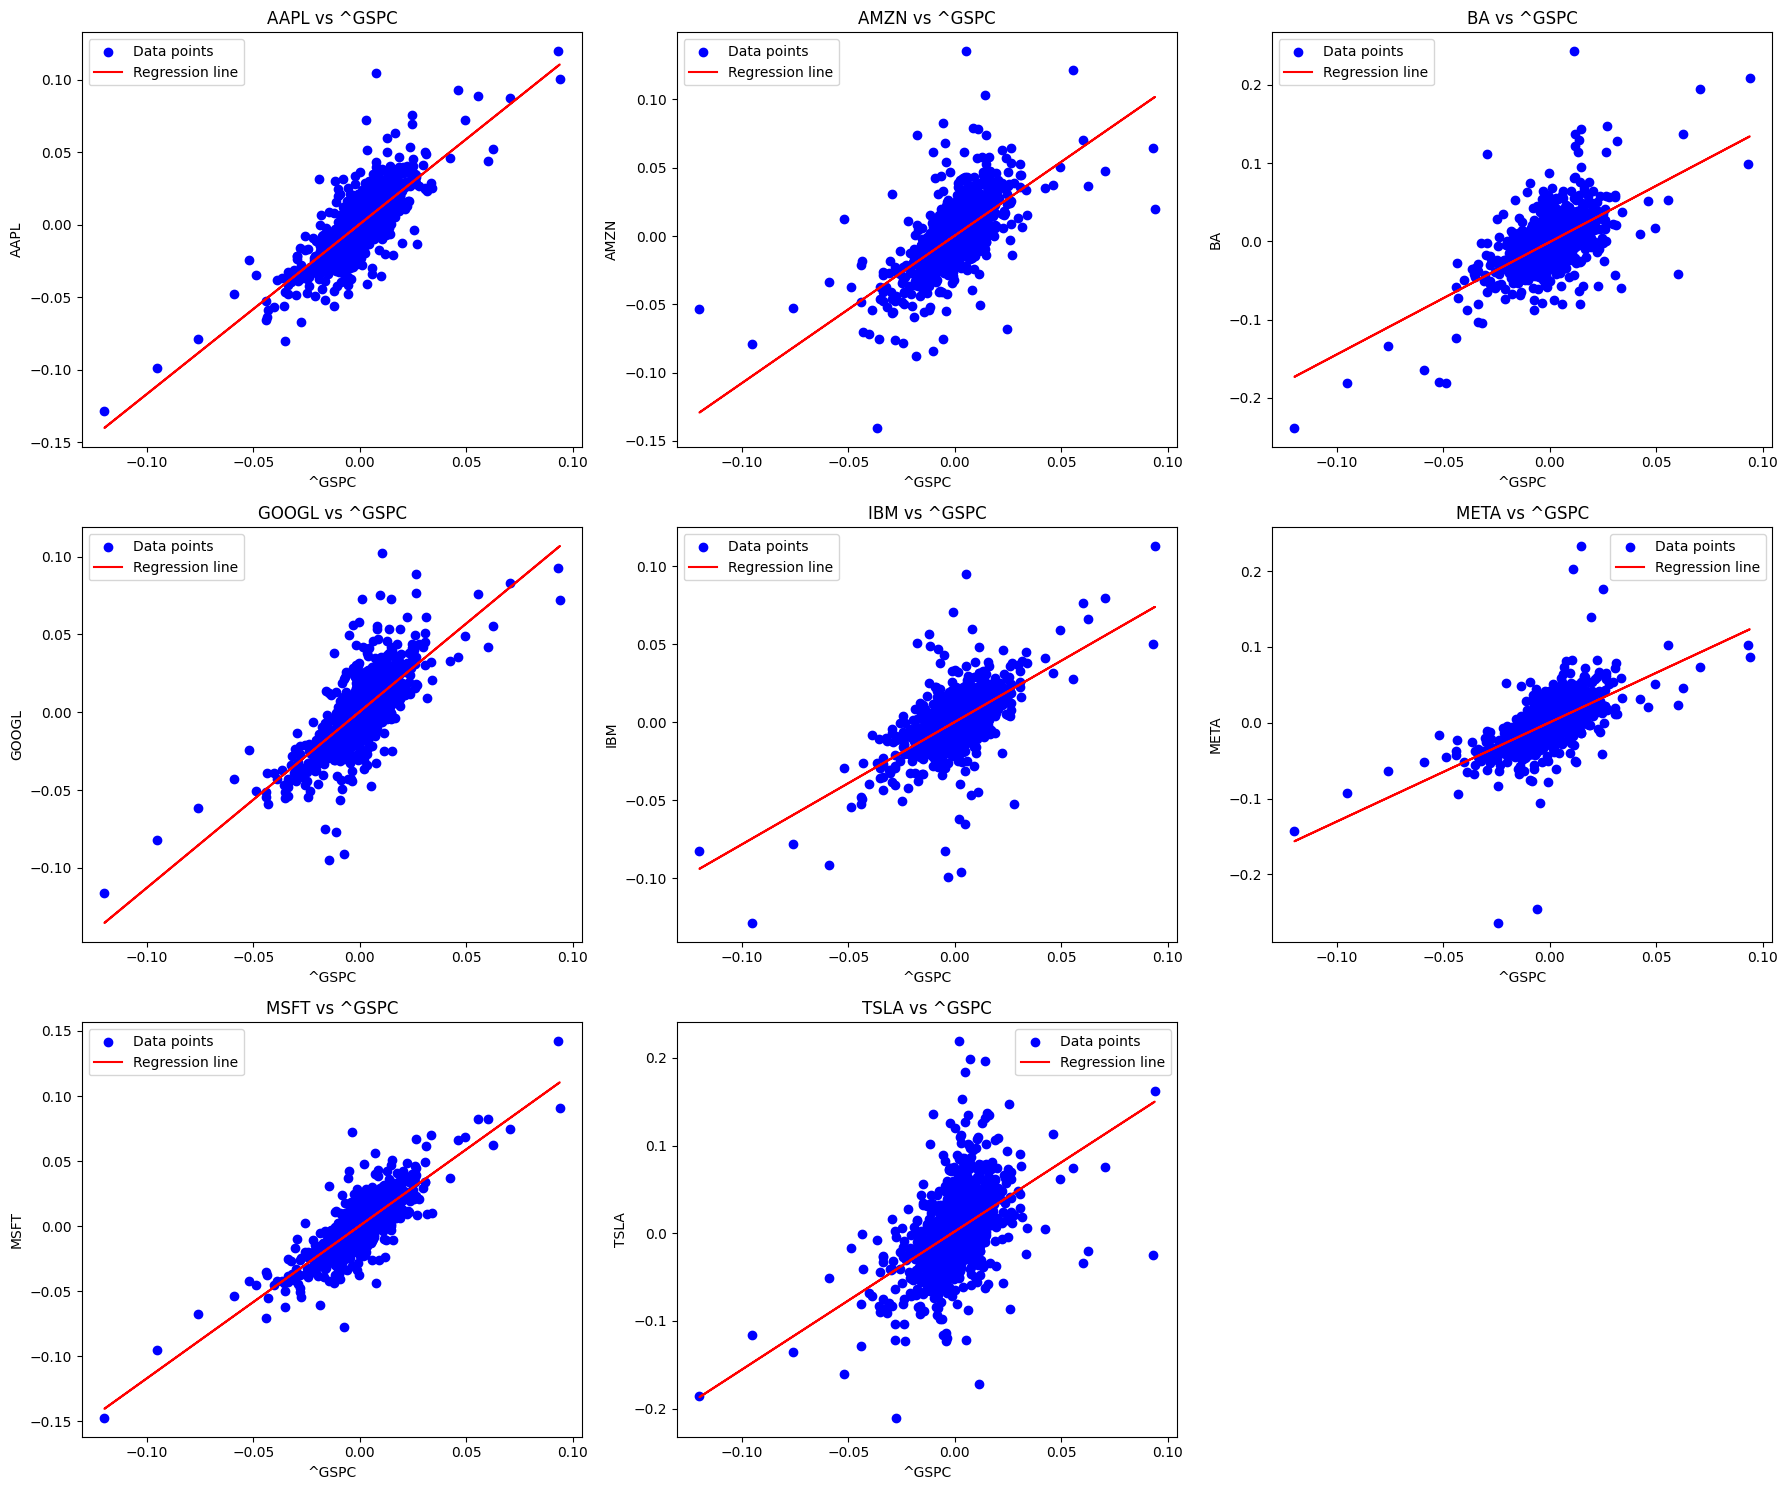

In [56]:
alpha = {}
beta = {}

stock_columns = [col for col in stocks_df.columns if col != index_ticker]
n = len(stock_columns)

# Define subplot grid size (square-like layout)
cols = 3  # change this if you want more columns
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()  # Flatten in case of multiple rows

for index, col in enumerate(stock_columns):
  ax = axes[index]
  
  # Extract the data
  x = returns_df[index_ticker]
  y = returns_df[col]

  # Compute beta & alpha
  beta_value, alpha_value = beta_using_polyfit(returns_df, col, index_ticker)

  # Create the plot
  ax.scatter(x, y, color='blue', label='Data points')
    
  # Regression line
  y_pred = alpha_value + beta_value * x
  ax.plot(x, y_pred, color='red', label='Regression line')

  ax.set_title(f'{col} vs {index_ticker}')
  ax.set_xlabel(index_ticker)
  ax.set_ylabel(col)
  ax.legend()
 
  beta[col] = beta_value
  alpha[col] = alpha_value
  
# Remove unused subplots (if any)
for j in range(index + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Step 7: Calculate the CAPM for a Portfolio of Stocks

In [57]:
# List of stock names
stock_names = list(beta.keys())

# Expected returns for each stock
ER = {}
for stock in stock_names:
  expected_return = risk_free_rate + beta[stock] * (rm - risk_free_rate)
  print(f"Expected Return of {stock} using CAPM: {expected_return:.2%}")
  ER[stock] = expected_return

Expected Return of AAPL using CAPM: 16.24%
Expected Return of AMZN using CAPM: 15.12%
Expected Return of BA using CAPM: 19.46%
Expected Return of GOOGL using CAPM: 15.75%
Expected Return of IBM using CAPM: 11.53%
Expected Return of META using CAPM: 17.87%
Expected Return of MSFT using CAPM: 16.25%
Expected Return of TSLA using CAPM: 21.15%


#### Step 8: Constructing an Equal Weighted Portfolio to each Stock

In [58]:
weight = 1 / len(stock_names)
print(f"\nEqual Weight for each stock in the portfolio: {weight:.4f}")

portfolio_return = 0
for stock in stock_names:
  portfolio_return += ER[stock] * weight
  
print(f"\nExpected Return of the Portfolio using CAPM: {portfolio_return:.2%}")


Equal Weight for each stock in the portfolio: 0.1250

Expected Return of the Portfolio using CAPM: 16.67%
